In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
sys.path.append("../../../../")
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *
from ADFWI.fwi         import *
import matplotlib
matplotlib.rc('font',family="Times New Roman")


# model
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 50, 50          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 1600, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(7400, 7400+dx*nx, nx)
z = np.linspace(12*dz, (dz+12)*nz, nz)
true_model   = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6,rcv_depth=0,mask_extra_detph=0)

# Initialize primary wave velocity (vp), Shear wave velocity (vs) and density (rho) for the model.
vp_init  = smooth_model['vp'].T
vs_init  = smooth_model['vs'].T
rho_init = smooth_model['rho'].T

# Extract true model properties for comparison.
vp_true = true_model['vp'].T 
vs_true = true_model['vs'].T 
rho_true = true_model['rho'].T 

src_z = np.array([45])*dx
src_x = np.array([25])*dx

rcv_z = np.array([1  for i in range(0,nx,1)])*dx
rcv_x = np.array([j  for j in range(0,nx,1)])*dx

# velocity model
z = np.arange(nz)*dz/1000
x = np.arange(nx)*dx/1000
z_mesh,x_mesh = np.meshgrid(x,z)

In [15]:
def add_right_cax(ax, pad, width):
    axpos = ax.get_position()
    caxpos = matplotlib.transforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

def normalize(data):
    return (data - data.min())/(data.max() - data.min())

def plot_gradient_cmp(adfwi_grad,perturbation_grad,cmap_vel="coolwarm",cmap_grad = "Spectral",save_path="",show=True):
    fig, axs = plt.subplots(
        3, 2, gridspec_kw={"width_ratios": [1,1], "height_ratios": [5,5, 1]},figsize=(16,18)
    )
    axs[0][0].pcolormesh(z_mesh,x_mesh,vp_true,cmap=cmap_vel,vmin=vp_true.min(),vmax=vp_true.max())
    axs[0][0].scatter(rcv_x/1000,rcv_z/1000,c='w',marker="v",s=20)
    axs[0][0].scatter(src_x/1000,src_z/1000,c='r',marker="*",s=100)
    axs[0][0].invert_yaxis()
    axs[0][0].tick_params(labelsize = 20)
    axs[0][0].set_ylabel("Depth (km)",fontsize=20)
    axs[0][0].set_xlabel("Distance (km)",fontsize=20)
    axs[0][0].text(1.4,1.95,"True Model",c='k',fontsize=20)

    im1 = axs[0][1].pcolormesh(z_mesh,x_mesh,vp_init,cmap=cmap_vel,vmin=vp_true.min(),vmax=vp_true.max())
    axs[0][1].invert_yaxis()
    axs[0][1].tick_params(labelsize = 20)
    axs[0][1].set_ylabel("Depth (km)",fontsize=20)
    axs[0][1].set_xlabel("Distance (km)",fontsize=20)
    axs[0][1].text(1.4,1.95,"Initial Model",c='k',fontsize=20)

    cax1 = add_right_cax(axs[0][1], pad=0.02, width=0.02)
    cbar1 = fig.colorbar(im1, cax=cax1)
    cbar1.ax.tick_params(labelsize=16)

    index1 = 25
    index2 = 25

    axs[1][0].pcolormesh(z_mesh,x_mesh,adfwi_grad,cmap=cmap_grad)
    axs[1][0].axvline(x = index1*dx/1000,c='k',linestyle="--",linewidth=2,zorder=10)
    axs[1][0].axhline(y = index2*dx/1000,c='k',linestyle="--",linewidth=2,zorder=10)
    axs[1][0].invert_yaxis()
    axs[1][0].tick_params(labelsize = 20)
    axs[1][0].set_ylabel("Depth (km)",fontsize=20)
    axs[1][0].set_xlabel("Distance (km)",fontsize=20)
    axs[1][0].text(1.05,1.95,"Gradient Calculate by AD",c='k',fontsize=18,zorder=20)

    im2 = axs[1][1].pcolormesh(z_mesh,x_mesh,-perturbation_grad,cmap=cmap_grad)
    axs[1][1].axvline(x = index1*dx/1000,c='#CC011F',linestyle="--",linewidth=2,zorder=10)
    axs[1][1].axhline(y = index2*dx/1000,c='#CC011F',linestyle="--",linewidth=2,zorder=10)
    axs[1][1].invert_yaxis()
    axs[1][1].tick_params(labelsize = 20)
    axs[1][1].set_ylabel("Depth (km)",fontsize=20)
    axs[1][1].set_xlabel("Distance (km)",fontsize=20)
    axs[1][1].text(1.05,1.95,"Gradient Calculate by FD",c='k',fontsize=18,zorder=10)

    cax2 = add_right_cax(axs[1][1], pad=0.02, width=0.02)
    cbar2 = fig.colorbar(im2, cax=cax2)
    cbar2.ax.tick_params(labelsize=16)

    adswit_acoustic_grad_single = -adfwi_grad[index1,:]
    perturb_grad_single = perturbation_grad[index1,:]
    diff1 = normalize(adswit_acoustic_grad_single) - normalize(perturb_grad_single)
    axs[2][0].plot(np.arange(len(perturb_grad_single))*dx/1000,normalize(adswit_acoustic_grad_single),c='k',linewidth=2,label="AD")
    axs[2][0].plot(np.arange(len(perturb_grad_single))*dx/1000,normalize(perturb_grad_single), c='#CC011F',linestyle="--",label="Numerical")
    axs[2][0].tick_params(labelsize = 20)
    axs[2][0].tick_params(labelsize = 20)
    axs[2][0].set_ylabel("Normalized Gradient",fontsize=20)
    axs[2][0].set_xlabel("Distance (km)",fontsize=20)

    adswit_acoustic_grad_single = -adfwi_grad[:,index2]
    perturb_grad_single         = perturbation_grad[:,index2]
    diff2 = normalize(adswit_acoustic_grad_single) - normalize(perturb_grad_single)
    axs[2][1].plot(np.arange(len(perturb_grad_single))*dx/1000,normalize(adswit_acoustic_grad_single),c='k',linewidth=2,label="AD")
    axs[2][1].plot(np.arange(len(perturb_grad_single))*dx/1000,normalize(perturb_grad_single),c='#CC011F',linestyle="--",label="Numerical")
    axs[2][1].tick_params(labelsize = 20)
    axs[2][1].tick_params(labelsize = 20)
    axs[2][1].set_ylabel("Normalized Gradient",fontsize=20)
    axs[2][1].set_xlabel("Depth (km)",fontsize=20)
    if not save_path == "":
        plt.savefig(save_path,bbox_inches="tight",dpi=300)
    if show:
        plt.show()

In [19]:
project_path = "./examples/gradient_checking/Elastic-Marmousi2/data/"

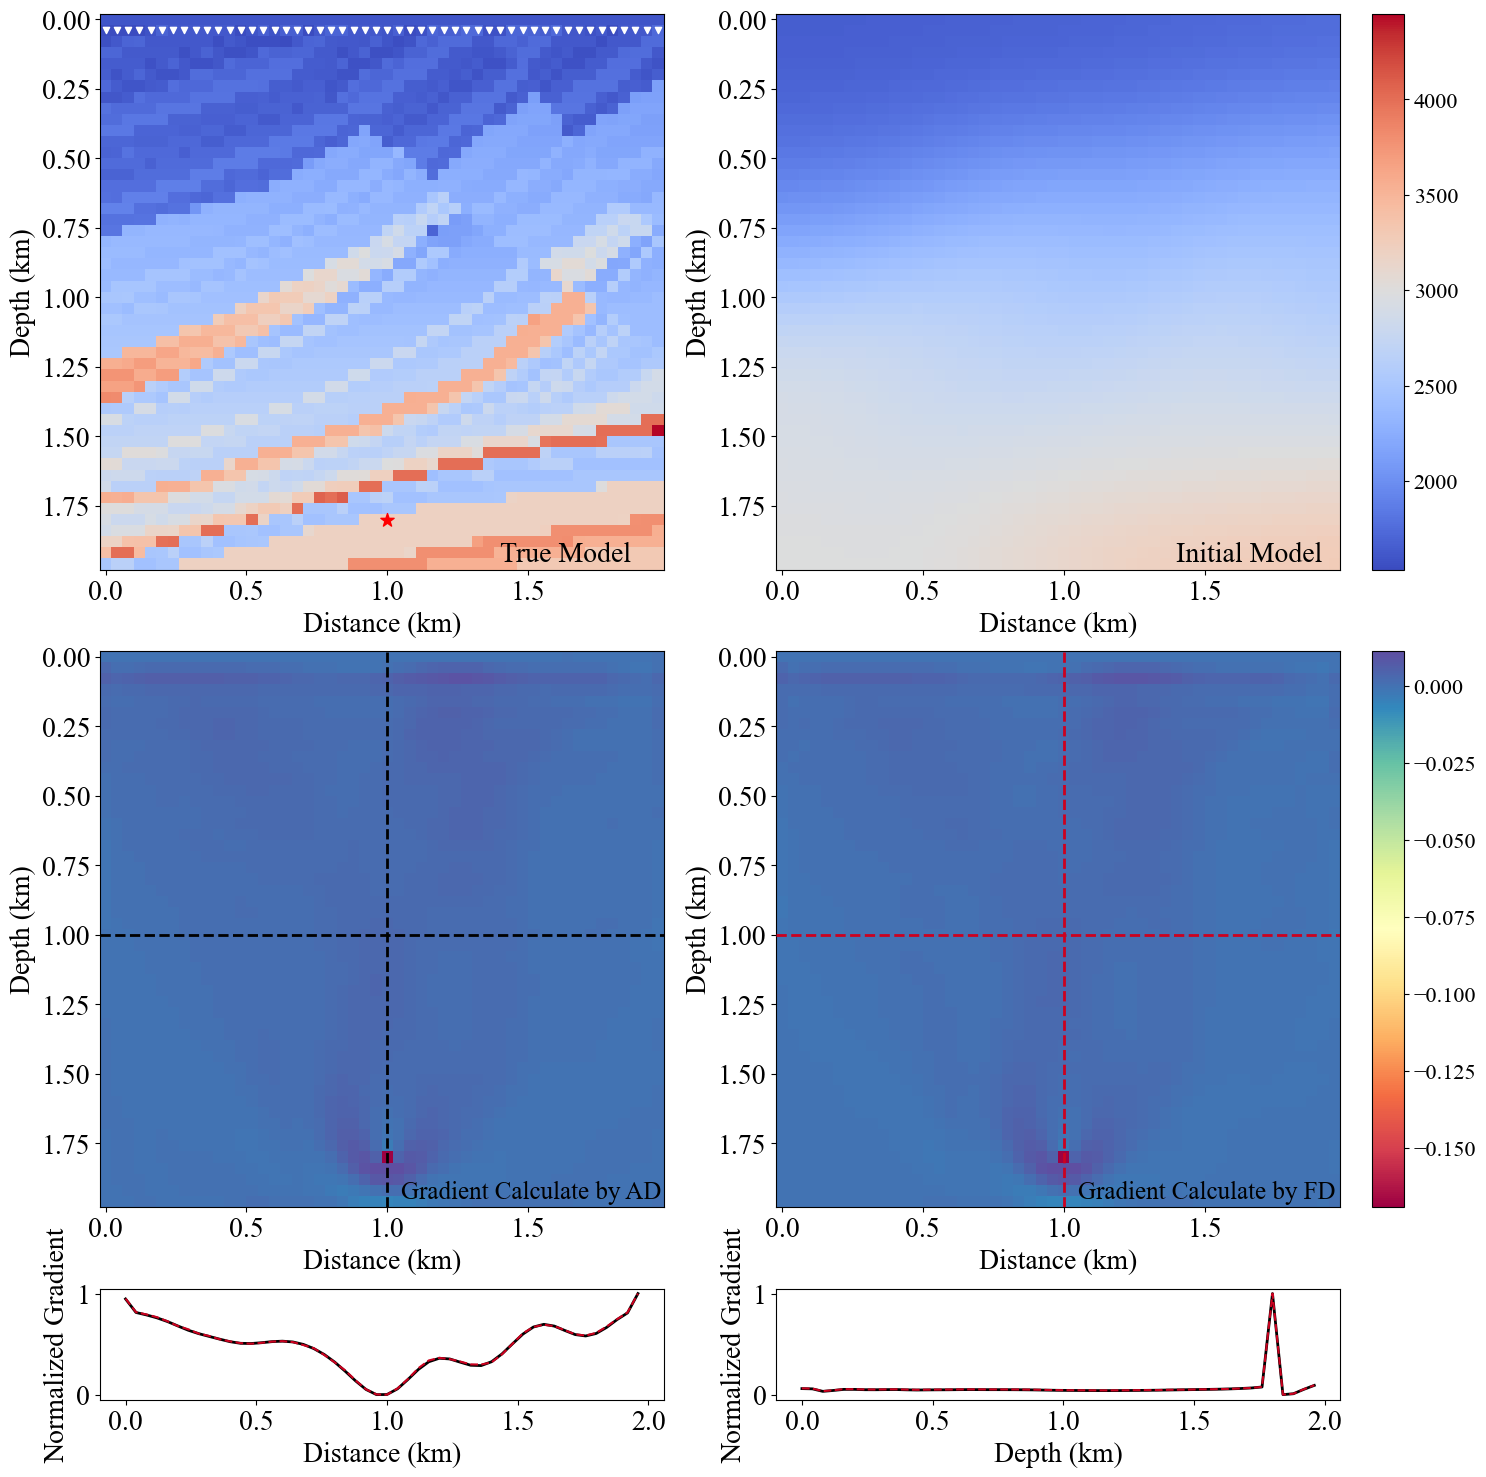

In [20]:
adfwi_grad        = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-AD/grad_vp.npz")["data"]
perturbation_grad = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-FD/vp/grad_vp.npz")["data"]

plot_gradient_cmp(adfwi_grad,perturbation_grad,cmap_vel="coolwarm",cmap_grad = "Spectral",save_path=os.path.join(project_path,"Elastic_vp_grad.png"),show=True)

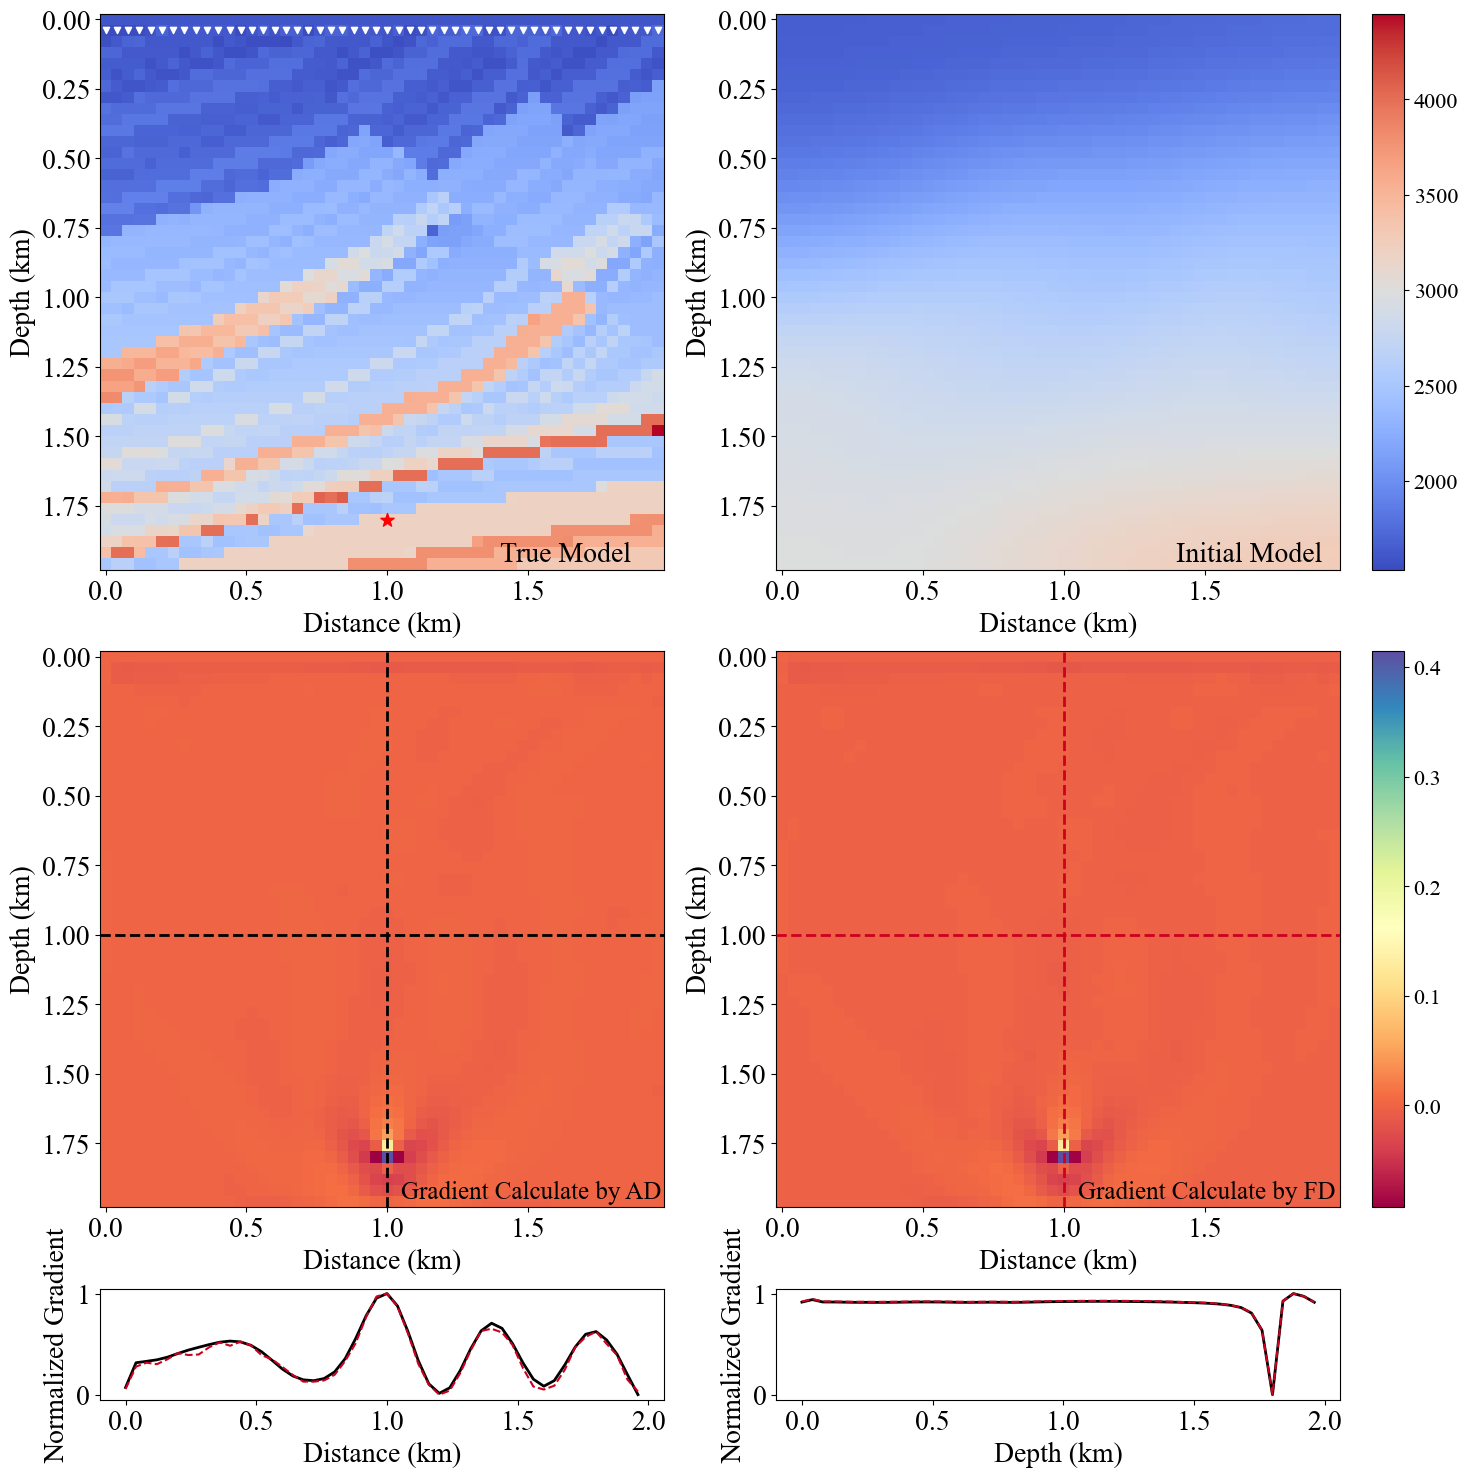

In [21]:
adfwi_grad        = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-AD/grad_vs.npz")["data"]
perturbation_grad = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-FD/vs/grad_vs.npz")["data"]

plot_gradient_cmp(adfwi_grad,perturbation_grad,cmap_vel="coolwarm",cmap_grad = "Spectral",save_path=os.path.join(project_path,"Elastic_vs_grad.png"),show=True)

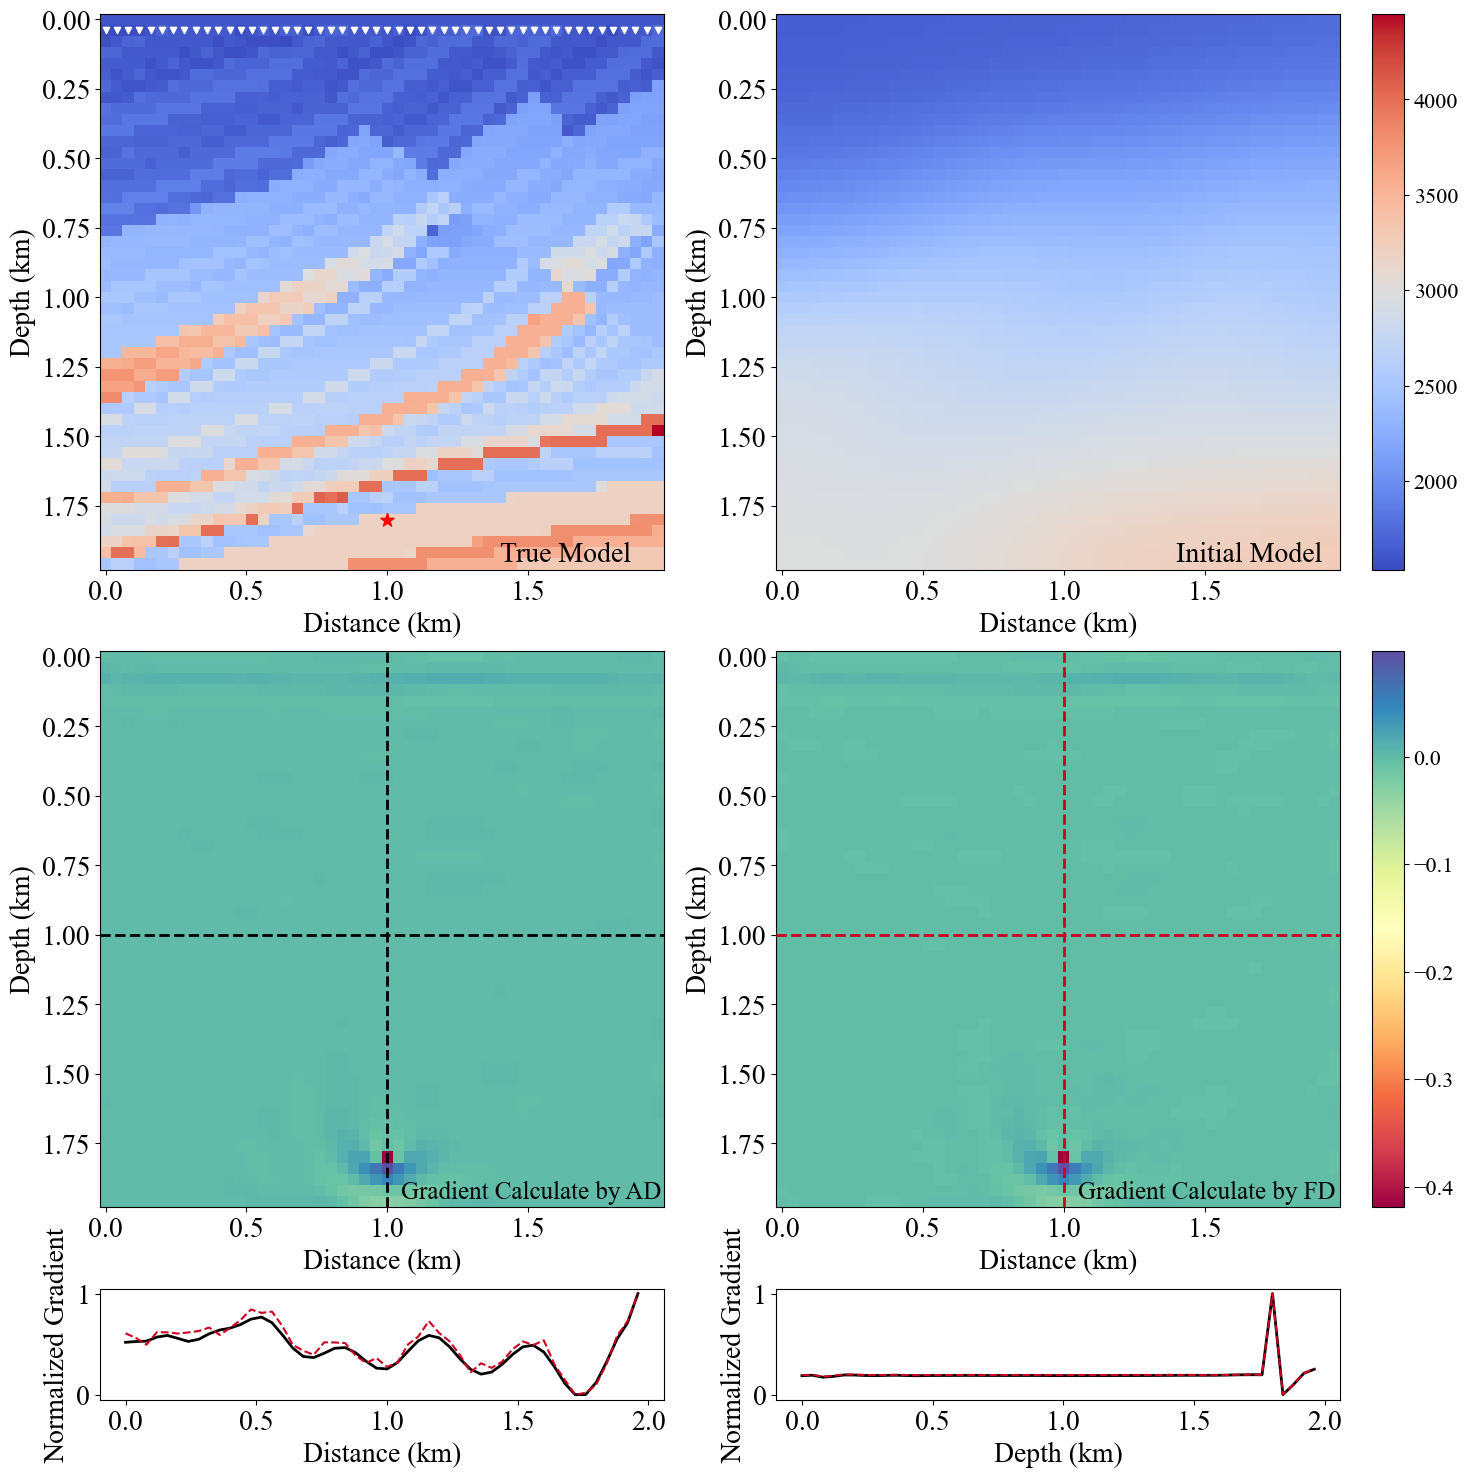

In [22]:
adfwi_grad        = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-AD/grad_rho.npz")["data"]
perturbation_grad = np.load("./examples/gradient_checking/Elastic-Marmousi2/data/inversion-FD/rho/grad_rho.npz")["data"]

plot_gradient_cmp(adfwi_grad,perturbation_grad,cmap_vel="coolwarm",cmap_grad = "Spectral",save_path=os.path.join(project_path,"Elastic_rho_grad.png"),show=True)